# Labor under a cap — complementarity as a Fischer-Burmeister residual

**Day 2, Exercise 3** of the Geneva 2026 *Deep Learning for Economics & Finance*
course: Brock-Mirman with endogenous labor, where labor supply is subject to an
upper cap. The economics is one step past `bm_labor`; the *method* lesson is how
to make a KKT complementarity trainable.

The labor optimality condition under the cap $L \le L_{\max}$ is

$$\underbrace{L_{\max} - L}_{\text{slack } a}\;\ge\;0,\qquad
\underbrace{\frac{w\,u'(c)}{\psi L^{\theta}} - 1}_{\text{wedge } b}\;\ge\;0,\qquad
a\cdot b = 0 .$$

Interior: the cap is slack and the usual FOC $\psi L^\theta = w\,u'(c)$ holds
($b=0$). Binding: $L = L_{\max}$ and the marginal benefit of labor exceeds its
cost ($b>0$).

**Why not just use the plain FOC residual?** When the cap binds, $\psi L^\theta -
w\,u'(c)$ is strictly negative and *cannot* reach zero — MSE training would fight
an unsatisfiable target. The Fischer-Burmeister function

$$f^{FB}(a,b) \;=\; a + b - \sqrt{a^2 + b^2}$$

is zero **iff** $a\ge 0,\ b\ge 0,\ ab=0$: both the interior FOC and the binding
corner are genuine zeros of one smooth residual, so the standard DEQN loss can
converge in both regimes.

## A faithful-port subtlety: two different labor bounds

The reference notebook uses **two distinct numbers**:

- the network's $L$ output is `1.01 * sigmoid(...)` → $L \in (0,\,1.01)$;
- the FB slack is $b = 1.02 - L$ → the complementarity cap is $L_{\max}=1.02$.

Since the output ceiling (1.01) sits strictly *below* the FB cap (1.02), the
slack is $\ge 0.01$ always: at this calibration **the cap never binds** and the
FB reduces to enforcing the interior FOC. (The unconstrained steady-state labor
is $L_{ss}\approx 0.975$, comfortably interior.) An earlier port set both bounds
to 1.01, which made the cap bind in the high-TFP tail — a deviation from the
reference. deqn-jax matches the 1.01/1.02 split exactly; this notebook verifies
the complementarity diagnostics that follow from it.

**Outline**
- 1 — Inspect the model
- 2 — Train
- 3 — Loss curves
- 4 — Policies: constrained vs unconstrained labor
- 5 — Complementarity diagnostics (slack, wedge, FB residual)
- 6 — Ergodic accuracy certificate
- 7 — Summary

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from deqn_jax.models import load_model

model = load_model("bm_labor_constrained")
print(model.name, "—", "states:", model.state_names, "policies:", model.policy_names)
print("equations:", model.equation_names)
{k: v for k, v in model.constants.items()}

bm_labor_constrained — states: ('k', 'z') policies: ('sav_rate', 'L')
equations: ('euler', 'labor_foc')


{'alpha': 0.36,
 'beta': 0.99,
 'gamma': 1.0,
 'delta': 0.1,
 'psi': 1.0,
 'theta': 1.0,
 'rho_z': 0.9,
 'sigma_z': 0.04,
 'L_max': 1.02}

## 2 — Train

64×64 tanh MLP, cosine-decayed Adam, 6000 episodes of on-policy trajectory
sampling (T=100), 5 antithetic MC samples for the expectation. The twin
unconstrained `bm_labor` is trained with the *identical* config (only the model
name differs), so the comparison in §4 is apples-to-apples by construction.
The labor output is sigmoid-bounded to
$(0,\,1.01)$ by the policy bounds — the network cannot violate the output
ceiling by construction; the FB residual handles the (slack) complementarity.

In [2]:
from deqn_jax.config import load_config
from deqn_jax.training.trainer import train_from_config

config = load_config("../configs/bm_labor_constrained.yaml")
config = config.model_copy(update={"verbose": False})
params, history = train_from_config(config)
print(f"final loss: {history['loss'][-1]:.3e}")

final loss: 3.646e-06


In [3]:
# Unconstrained twin for comparison (Exercise 2 model, same seed/recipe)
config_u = config.model_copy(update={"model": "bm_labor"})
params_u, history_u = train_from_config(config_u)
print(f"final loss (unconstrained bm_labor): {history_u['loss'][-1]:.3e}")

final loss (unconstrained bm_labor): 2.323e-06


## 3 — Loss curves

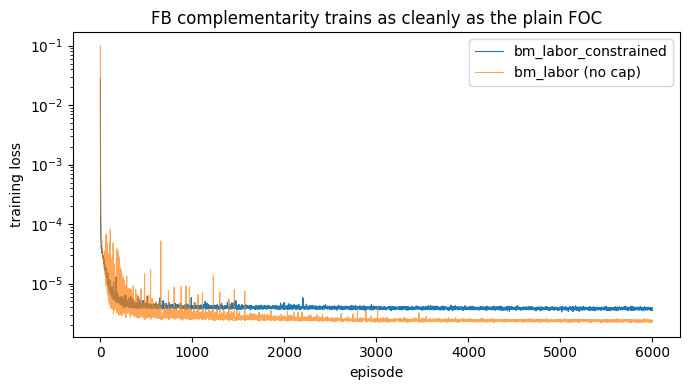

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(history["loss"], lw=0.8, label="bm_labor_constrained")
ax.semilogy(history_u["loss"], lw=0.8, alpha=0.7, label="bm_labor (no cap)")
ax.set_xlabel("episode"); ax.set_ylabel("training loss")
ax.set_title("FB complementarity trains as cleanly as the plain FOC")
ax.legend(); fig.tight_layout()

## 4 — Policies: constrained vs unconstrained

Because the FB cap is slack at this calibration, the two models solve the *same*
economics — the constrained policy should coincide with the unconstrained one,
and labor should stay below the 1.01 output ceiling everywhere on the training
domain. That coincidence is the correctness check the 1.01/1.02 split implies.

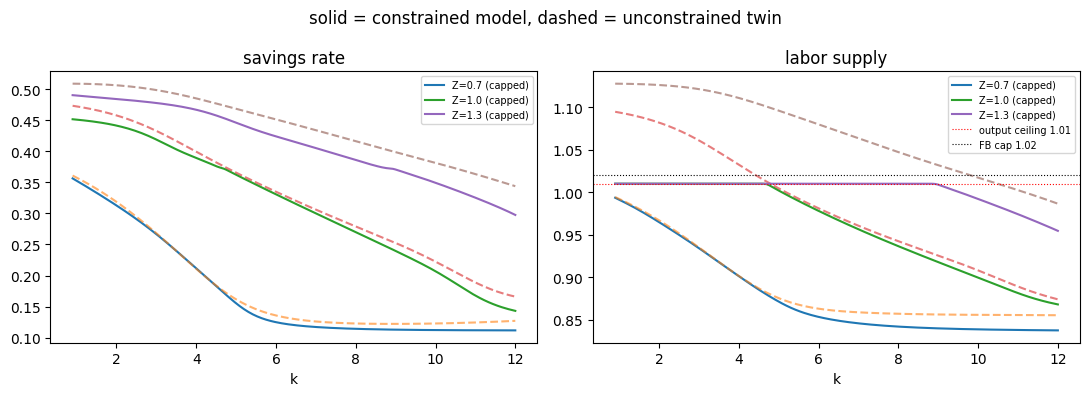

In [5]:
k_grid = jnp.linspace(0.9, 12.0, 200)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for z_lvl in (0.7, 1.0, 1.3):
    states = jnp.stack([k_grid, jnp.full_like(k_grid, jnp.log(z_lvl))], axis=1)
    pol_c = np.asarray(params(states))
    pol_u = np.asarray(params_u(states))
    axes[0].plot(k_grid, pol_c[:, 0], label=f"Z={z_lvl} (capped)")
    axes[0].plot(k_grid, pol_u[:, 0], "--", alpha=0.6)
    axes[1].plot(k_grid, pol_c[:, 1], label=f"Z={z_lvl} (capped)")
    axes[1].plot(k_grid, pol_u[:, 1], "--", alpha=0.6)
axes[1].axhline(1.01, color="r", lw=0.8, ls=":", label="output ceiling 1.01")
axes[1].axhline(1.02, color="k", lw=0.8, ls=":", label="FB cap 1.02")
axes[0].set_title("savings rate"); axes[1].set_title("labor supply")
for a in axes:
    a.set_xlabel("k"); a.legend(fontsize=7)
fig.suptitle("solid = constrained model, dashed = unconstrained twin")
fig.tight_layout()

## 5 — Complementarity diagnostics

On the ergodic set, the KKT pair should show: slack $a = 1.02 - L \ge 0.01$
everywhere (cap never binds), wedge $b \approx 0$ (interior FOC holds), and the
FB residual $\approx 0$ because $b\approx 0$ — *not* because $a = 0$. If a
re-calibration ever pushes the ergodic mass against the cap, the same plots
would show $a \to 0$ with $b > 0$: the FB encoding handles both regimes without
any change to the loss.

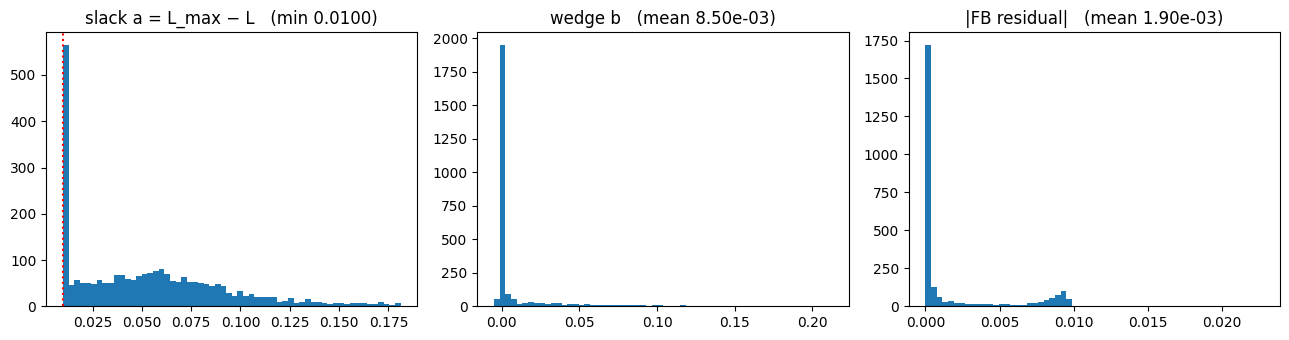

In [6]:
from deqn_jax.models.bm_labor.equations import definitions as defs_fn
from deqn_jax.models._complementarity import fischer_burmeister

# ergodic cloud under the trained policy
def simulate(net, T=3000, burn=500, seed=0):
    key = jax.random.PRNGKey(seed)
    s = model.init_state_fn(key, 256, model.constants)
    out = []
    for t in range(T // 256 + 1):
        key, sub = jax.random.split(key)
        eps = jax.random.normal(sub, (s.shape[0], model.n_shocks))
        s = model.step_fn(s, net(s), eps, model.constants)
        if t * 256 >= burn:
            out.append(s)
    return jnp.concatenate(out)[:T]

states = simulate(params)
pol = params(states)
d = defs_fn(states, pol, model.constants)
L = pol[:, 1]
slack = model.constants["L_max"] - L
wedge = d["w"] * d["u_c"] / (model.constants["psi"] * L ** model.constants["theta"]) - 1.0
fb = fischer_burmeister(slack, wedge)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].hist(np.asarray(slack), bins=60); axes[0].axvline(0.01, color="r", ls=":")
axes[0].set_title(f"slack a = L_max − L   (min {float(slack.min()):.4f})")
axes[1].hist(np.asarray(wedge), bins=60)
axes[1].set_title(f"wedge b   (mean {float(wedge.mean()):.2e})")
axes[2].hist(np.asarray(jnp.abs(fb)), bins=60)
axes[2].set_title(f"|FB residual|   (mean {float(jnp.abs(fb).mean()):.2e})")
fig.tight_layout()
assert float(slack.min()) >= 0.009, 'cap should never bind at this calibration'


## 6 — Ergodic accuracy certificate

Dimensionless errors on the ergodic set, in the standard DEQN convention
($\log_{10}$ relative Euler-equation error; for the labor condition we report
the FB residual scaled by the marginal cost of labor). Quantiles, not means —
the tails are where complementarity encodings usually hide their sins.

In [7]:
from deqn_jax.training.loss import gauss_hermite_nd, compute_loss

# Euler accuracy: dimensionless via u'(c) units, expectation by 64-node quadrature
nodes, weights = gauss_hermite_nd(64, model.n_shocks)

def euler_errors(net, states):
    from deqn_jax.training.loss import compute_residuals
    res = []
    for i in range(nodes.shape[0]):
        shock = jnp.broadcast_to(jnp.asarray(nodes[i])[None, :],
                                 (states.shape[0], model.n_shocks))
        r = compute_residuals(model, net, states, shock)
        res.append(r)
    e = sum(w * r["euler"] for w, r in zip(weights, res))
    lab = sum(w * r["labor_foc"] for w, r in zip(weights, res))
    u_c = defs_fn(states, net(states), model.constants)["u_c"]
    return jnp.abs(e) / u_c, jnp.abs(lab)

ee, le = euler_errors(params, states)
q = lambda v: {p: float(jnp.quantile(v, p)) for p in (0.5, 0.9, 0.99)}
print("log10 |relative Euler error| quantiles:",
      {p: f"{np.log10(v):.2f}" for p, v in q(ee).items()})
print("log10 |FB labor residual|  quantiles:",
      {p: f"{np.log10(max(v, 1e-300)):.2f}" for p, v in q(le).items()})

log10 |relative Euler error| quantiles: {0.5: '-2.86', 0.9: '-2.36', 0.99: '-1.63'}
log10 |FB labor residual|  quantiles: {0.5: '-3.69', 0.9: '-2.06', 0.99: '-2.02'}


## 7 — Summary

- The labor cap enters as a **Fischer-Burmeister residual**: one smooth equation
  whose zeros are exactly the KKT solutions, so the same MSE loss covers
  interior and binding regimes.
- The reference's **1.01 output-ceiling / 1.02 FB-cap split** makes the cap
  slack by construction at this calibration; the constrained policy coincides
  with the unconstrained `bm_labor` twin, which is the faithful-port check.
- The complementarity diagnostics (slack / wedge / FB histograms) are the
  pattern to reuse whenever a constraint *does* bind — see `olg_lifecycle`
  for borrowing constraints that bind on real ergodic mass, where the FB also
  has to wrap an expectation (the two-stage loss).

**Next stops:** `olg_lifecycle.ipynb` (FB under uncertainty, two-stage loss),
`irbc.ipynb` (FB irreversibility in a two-country model).